In [36]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph

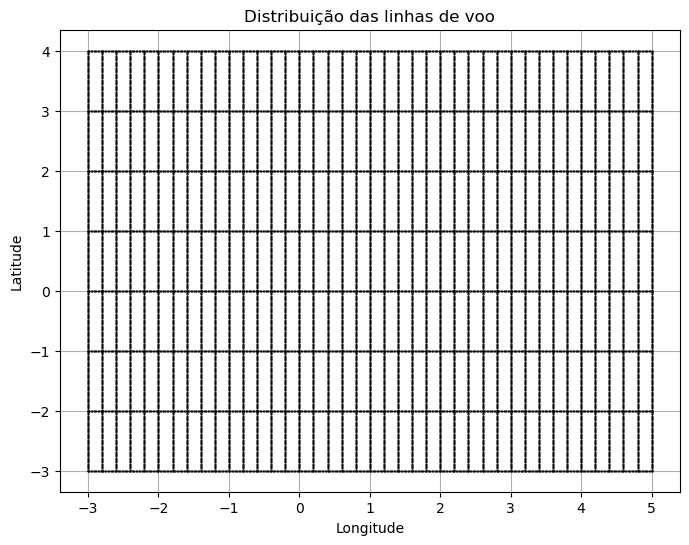

In [37]:
ellipsoid = bl.WGS84
 
region_airbone = [-3, 5, -3, 4]  

spacing_1 = (0.02, 0.2) 
coordinates_1 = vd.grid_coordinates(region=region_airbone, spacing=spacing_1, extra_coords=ellipsoid.mean_radius + 500)


spacing_2 = (1, 0.02) 
coordinates_2 = vd.grid_coordinates(region=region_airbone, spacing=spacing_2, extra_coords=ellipsoid.mean_radius + 500)


coordinates = np.concatenate((coordinates_1[0].ravel(), coordinates_2[0].ravel())), \
              np.concatenate((coordinates_1[1].ravel(), coordinates_2[1].ravel())), \
              np.concatenate((coordinates_1[2].ravel(), coordinates_2[2].ravel()))


plt.figure(figsize=(8, 6))
plt.plot(coordinates[0], coordinates[1], ".k", markersize=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição das linhas de voo")
plt.grid()
plt.show()


In [38]:
inclination, declination = 30, 20

# Syntetic dike

dike_size = 100
dike = sph.profile_points((1,-3), (5,1), dike_size, ellipsoid.mean_radius - 4.0e4)

# Syntetic dipoles
n_dipoles = 3
dipoles = tuple(c.ravel() for c in vd.scatter_points(region= region_airbone, size= n_dipoles, extra_coords= ellipsoid.mean_radius - 4e4, random_state=7))

#Data

magnetic_field = sph.forward_modeling_spherical(coordinates,
    dipoles,
magnetic_moments = hm.magnetic_angles_to_vec(
    np.full(n_dipoles, 1e12),  
    np.full(n_dipoles, inclination),  
    np.full(n_dipoles, declination)   
)
)
dike_and_dipoles = hm.total_field_anomaly(magnetic_field, inclination, declination)

magnetic_moments_dike = hm.magnetic_angles_to_vec(
    np.full(dike_size, 1e10),  
    np.full(dike_size, inclination),  
    np.full(dike_size, declination)   
)


magnetic_field = sph.forward_modeling_spherical(coordinates, dike, magnetic_moments_dike)

dike_and_dipoles += hm.total_field_anomaly(magnetic_field, inclination, declination)

(np.float64(-3.4), np.float64(5.4), np.float64(-3.35), np.float64(4.35))

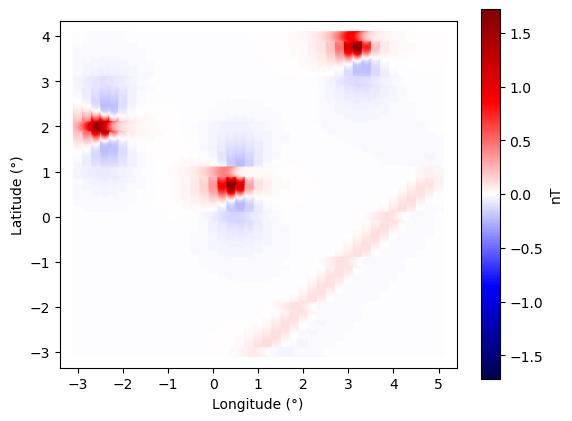

In [39]:
scale = vd.maxabs(dike_and_dipoles)
plt.scatter(coordinates[0], coordinates[1],  c = dike_and_dipoles, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [40]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 1.9e5
)


eql_inc = 90
eql_dec = 0
A = sph.jacobian(coordinates, equivalent_layer, eql_inc, eql_dec, inclination, declination)

In [ ]:
damping = 1e-30
coefficients = sph.calculate_coefficients(dike_and_dipoles, A, damping)

In [ ]:
# Make the coordinates of a regular grid
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region_airbone, spacing=0.09, extra_coords=ellipsoid.mean_radius - 200))

grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

magnetic_moment_foward = hm.magnetic_angles_to_vec(np.array([1]), np.array([(eql_inc)]), np.array([(eql_dec)]))

for j in range(m):
    dipole_foward = (equivalent_layer[0][j],equivalent_layer[1][j],equivalent_layer[2][j])
    b_foward = sph.forward_modeling_spherical(grid_coord,dipole_foward,magnetic_moment_foward)
    grid_data += coefficients[j] * hm.total_field_anomaly(b_foward, inclination, declination)

In [ ]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
    
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)


    dipole_latitudes, dipole_longitudes, dipole_radii = dipole_data

    for lat, lon, r, moment in zip(dipole_latitudes.flatten(), dipole_longitudes.flatten(), dipole_radii.flatten(), moments):
        dipole_coordinates = np.array([lat, lon, r])
        
        magnetic_field = sph.forward_modeling_spherical(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

    return grided_magnetic_anomaly

In [ ]:
grided_dd_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dike, np.full(dike_size, 1e9))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, dipoles, np.full(n_dipoles ,1e12))
diff = grid_data - grided_dd_anomaly

In [ ]:
plt.figure(figsize=(24, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1,3,1)
plt.tripcolor(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Predicted Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale2 = vd.maxabs(grided_dd_anomaly)
plt.subplot(1,3,2)
plt.tripcolor(grid_coord[0], grid_coord[1], grided_dd_anomaly, cmap="seismic", vmin=-scale2, vmax=scale2)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale3 = vd.maxabs(diff)
plt.subplot(1,3,3)
plt.tripcolor(grid_coord[0], grid_coord[1], diff, cmap="seismic", vmin=-scale3, vmax=scale3)
plt.colorbar(label='nT')
plt.title('Residuals')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")